In [8]:
import lightgbm as lgb
import xgboost as xgb
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
import os
assert os.path.exists("../data/processed/sampled_metadata.csv"), \
    "Chưa có sampled_metadata.csv — cần chạy length_grouping.py trước"

In [10]:
# Import libraries, and self-defined functions from models_gb.py, features.py, data_loader.py
import sys
import importlib
sys.path.append('../src')
import models_gb
importlib.reload(models_gb)
import data_loader
importlib.reload(data_loader)
from data_loader import load_and_preprocess_m4_monthly
from features import create_time_features_optimized, make_train_test_split
from models_gb import (
    train_lightgbm, train_xgboost,
    predict_lightgbm, predict_xgboost, optimize_xgboost_params, train_with_best_params
)
from evaluation import plot_actual_vs_predicted, calculate_metrics

In [11]:
sampled_metadata = pd.read_csv("../data/processed/sampled_metadata.csv")

train_df, test_df = load_and_preprocess_m4_monthly(
    "../data/raw/Train/Monthly-train.csv",
    "../data/raw/Test/Monthly-test.csv",
    series_ids=sampled_metadata["unique_id"].tolist()
)

# Gắn length_group, category vào train_df
train_df = train_df.merge(
    sampled_metadata[["unique_id", "category", "length_group"]],
    on="unique_id", how="left"
)
assert train_df["length_group"].isna().sum() == 0, "Có series thiếu length_group sau merge!"

# Create Features
train_df = create_time_features_optimized(train_df)
test_df = create_time_features_optimized(test_df)

# Split Train/Val
train_split, val_split = make_train_test_split(train_df, test_horizon=18)

--- Bước 1 & 2: Đọc và Melt dữ liệu ---
--- Bước 3: Tái tạo mốc thời gian ---
Hoàn thành! Kích thước Train: (90824, 3), Test: (8334, 3)


In [12]:
train_df.head()

,unique_id,ds,y,category,length_group,year,month,quarter,is_quarter_end,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12
0,M10200,1900-01-01,1154.0,Micro,short,1900,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M10200,1900-02-01,1159.0,Micro,short,1900,2,1,0,1154.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M10200,1900-03-01,1165.0,Micro,short,1900,3,1,0,1159.0,1154.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,M10200,1900-04-01,1155.0,Micro,short,1900,4,2,0,1165.0,1159.0,1154.0,NaN,NaN,1159.333374,5.507571,NaN,NaN,NaN,NaN
4,M10200,1900-05-01,1154.0,Micro,short,1900,5,2,0,1155.0,1165.0,1159.0,NaN,NaN,1159.666626,5.033223,NaN,NaN,NaN,NaN


In [13]:
train_df.describe()

,ds,y,year,month,quarter,is_quarter_end,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12
count,90824,90824.000000,90824.000000,90824.000000,90824.000000,90824.0,90361.000000,89898.000000,89435.000000,88046.000000,85268.000000,89435.000000,89435.000000,88046.000000,88046.000000,85268.000000,85268.000000
mean,1910-04-03 12:49:19.464459,4368.108566,1909.803202,6.427916,2.476790,0.0,4364.576172,4361.479004,4358.310059,4349.274902,4330.996582,4365.270020,248.210403,4366.075195,310.370911,4367.780273,374.269867
min,1900-01-01 00:00:00,20.000000,1900.000000,1.000000,1.000000,0.0,20.000000,65.480003,65.480003,65.480003,65.480003,69.473335,0.000000,74.120003,0.000000,80.537498,0.000000
25%,1904-02-01 00:00:00,1745.768400,1904.000000,3.000000,1.000000,0.0,1744.000000,1742.304077,1741.000000,1740.000000,1735.900024,1758.716675,20.000000,1766.676758,35.590260,1771.666626,54.329559
50%,1909-01-01 00:00:00,3548.259010,1909.000000,6.000000,2.000000,0.0,3544.100098,3542.153809,3540.327393,3539.000000,3520.000000,3589.725830,60.044430,3615.250000,91.433037,3636.991699,128.285889
75%,1915-07-01 00:00:00,6210.000000,1915.000000,9.000000,3.000000,0.0,6203.899902,6200.000000,6200.000000,6186.000000,6160.000000,6210.585938,200.158417,6220.512695,284.475922,6223.687500,378.894348
max,1932-07-01 00:00:00,57430.000000,1932.000000,12.000000,4.000000,0.0,57430.000000,57430.000000,57430.000000,57430.000000,57430.000000,49660.000000,29271.658203,46718.332031,23104.527344,38814.167969,21463.613281
std,NaN,3177.329159,7.289139,3.448048,1.116814,0.0,3170.923340,3167.265625,3163.749756,3153.583740,3132.332275,3104.157227,735.088745,3073.995850,759.020691,3041.536865,796.561401


In [14]:
# Prepare Features
feature_cols = [col for col in train_split.columns
                if col not in ['unique_id', 'ds', 'y', 'category', 'length_group']]
X_train = train_split[feature_cols].ffill()
y_train = train_split['y']
X_val = val_split[feature_cols].ffill()
y_val = val_split['y']

In [15]:
from models_gb import (
    optimize_lightgbm_params, optimize_xgboost_params,
    train_with_best_params, plot_optuna_results
)

# Tune LightGBM (giảm n_trials nếu deadline gấp, VD n_trials=30)
study_lgb = optimize_lightgbm_params(X_train, y_train, X_val, y_val, n_trials=50, timeout=1800)
print("Best LightGBM params:", study_lgb.best_trial.params)
print("Best LightGBM RMSE:", study_lgb.best_value)

[I 2026-09-04 10:51:31,167] A new study created in memory with name: no-name-810ba5a9-48e1-457c-af8d-e2b05cda2d5d
  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


Best trial: 0. Best value: 1282.91:   2%|▏         | 1/50 [00:30<24:53, 30.48s/it, 30.47/1800 seconds]

Did not meet early stopping. Best iteration is:
[458]	valid_0's rmse: 1282.91
[I 2026-09-04 10:52:01,646] Trial 0 finished with value: 1282.9128256543831 and parameters: {'learning_rate': 0.008468008575248327, 'num_leaves': 122, 'max_depth': 12, 'feature_fraction': 0.759195090518222, 'bagging_fraction': 0.4936111842654619, 'bagging_freq': 2, 'min_child_samples': 10, 'lambda_l1': 8.661761457749352, 'lambda_l2': 6.011150117432088}. Best is trial 0 with value: 1282.9128256543831.
Training until validation scores don't improve for 50 rounds


Best trial: 0. Best value: 1282.91:   4%|▍         | 2/50 [00:32<10:49, 13.54s/it, 32.15/1800 seconds]

...

Early stopping, best iteration is:
[252]	valid_0's rmse: 1247.26
[I 2026-09-04 10:54:55,576] Trial 47 finished with value: 1247.2600373009755 and parameters: {'learning_rate': 0.034484802828687385, 'num_leaves': 73, 'max_depth': 15, 'feature_fraction': 0.9061082097851964, 'bagging_fraction': 0.5158055213067334, 'bagging_freq': 2, 'min_child_samples': 79, 'lambda_l1': 0.44960935565536486, 'lambda_l2': 4.120378049753327}. Best is trial 42 with value: 1239.626155513733.
Training until validation scores don't improve for 50 rounds


Best trial: 48. Best value: 1237.83:  98%|█████████▊| 49/50 [03:31<00:06,  6.67s/it, 211.01/1800 seconds]

Early stopping, best iteration is:
[313]	valid_0's rmse: 1237.83
[I 2026-09-04 10:55:02,185] Trial 48 finished with value: 1237.8267601861019 and parameters: {'learning_rate': 0.02189952067351954, 'num_leaves': 50, 'max_depth': 11, 'feature_fraction': 0.859744284156313, 'bagging_fraction': 0.40784711651430633, 'bagging_freq': 4, 'min_child_samples': 60, 'lambda_l1': 2.2189870718421822, 'lambda_l2': 1.1306282925329252}. Best is trial 48 with value: 1237.8267601861019.
Training until validation scores don't improve for 50 rounds


Best trial: 49. Best value: 1237.46: 100%|██████████| 50/50 [03:36<00:00,  4.32s/it, 216.13/1800 seconds]

Early stopping, best iteration is:
[320]	valid_0's rmse: 1237.46
[I 2026-09-04 10:55:07,299] Trial 49 finished with value: 1237.4564471916492 and parameters: {'learning_rate': 0.02207018597330874, 'num_leaves': 50, 'max_depth': 10, 'feature_fraction': 0.8553154937930857, 'bagging_fraction': 0.41188882363401935, 'bagging_freq': 4, 'min_child_samples': 42, 'lambda_l1': 2.3415736430463983, 'lambda_l2': 0.8509692051244357}. Best is trial 49 with value: 1237.4564471916492.
Best LightGBM params: {'learning_rate': 0.02207018597330874, 'num_leaves': 50, 'max_depth': 10, 'feature_fraction': 0.8553154937930857, 'bagging_fraction': 0.41188882363401935, 'bagging_freq': 4, 'min_child_samples': 42, 'lambda_l1': 2.3415736430463983, 'lambda_l2': 0.8509692051244357}
Best LightGBM RMSE: 1237.4564471916492


In [16]:
# Tune XGBoost
study_xgb = optimize_xgboost_params(X_train, y_train, X_val, y_val, n_trials=50, timeout=1800)
print("Best XGBoost params:", study_xgb.best_trial.params)
print("Best XGBoost RMSE:", study_xgb.best_value)

[I 2026-09-04 10:55:07,312] A new study created in memory with name: no-name-489cd56c-5b7f-4053-9697-5163d76b2e4f
Best trial: 0. Best value: 1318:   2%|▏         | 1/50 [00:51<41:54, 51.31s/it, 51.31/1800 seconds]

[I 2026-09-04 10:55:58,620] Trial 0 finished with value: 1318.002765852745 and parameters: {'learning_rate': 0.008468008575248327, 'max_depth': 15, 'subsample': 0.839196365086843, 'colsample_bytree': 0.759195090518222, 'min_child_weight': 2, 'gamma': 0.7799726016810132, 'alpha': 0.5808361216819946, 'lambda': 8.661761457749352}. Best is trial 0 with value: 1318.002765852745.


Best trial: 0. Best value: 1318:   4%|▍         | 2/50 [00:55<18:58, 23.72s/it, 55.71/1800 seconds]

[I 2026-09-04 10:56:03,022] Trial 1 finished with value: 1331.148200872438 and parameters: {'learning_rate': 0.030834348179355788, 'max_depth': 12, 'subsample': 0.41235069657748147, 'colsample_bytree': 0.9819459112971965, 'min_child_weight': 9, 'gamma': 1.0616955533913808, 'alpha': 1.8182496720710062, 'lambda': 1.8340450985343382}. Best is trial 0 with value: 1318.002765852745.


Best trial: 2. Best value: 1317.19:   6%|▌         | 3/50 [01:06<13:59, 17.85s/it, 66.59/1800 seconds]

...

[I 2026-09-04 11:07:19,396] Trial 47 finished with value: 1305.7928414013372 and parameters: {'learning_rate': 0.04412866257141736, 'max_depth': 5, 'subsample': 0.4903030182635939, 'colsample_bytree': 0.4752457931741732, 'min_child_weight': 9, 'gamma': 0.6358115927116936, 'alpha': 1.998563446706529, 'lambda': 9.943019267014169}. Best is trial 42 with value: 1284.5586206760977.


Best trial: 42. Best value: 1284.56:  98%|█████████▊| 49/50 [12:16<00:03,  3.98s/it, 736.15/1800 seconds]

[I 2026-09-04 11:07:23,459] Trial 48 finished with value: 1318.7666780298512 and parameters: {'learning_rate': 0.06728136977118773, 'max_depth': 9, 'subsample': 0.5949546964976873, 'colsample_bytree': 0.40318681835977127, 'min_child_weight': 7, 'gamma': 2.0943041848672856, 'alpha': 1.1696255051482243, 'lambda': 3.7406366557994883}. Best is trial 42 with value: 1284.5586206760977.


Best trial: 42. Best value: 1284.56: 100%|██████████| 50/50 [12:18<00:00, 14.76s/it, 738.04/1800 seconds]

[I 2026-09-04 11:07:25,353] Trial 49 finished with value: 1300.2374931512597 and parameters: {'learning_rate': 0.02603913478490582, 'max_depth': 6, 'subsample': 0.6324968201257859, 'colsample_bytree': 0.4419319556656047, 'min_child_weight': 9, 'gamma': 1.783876646896395, 'alpha': 2.9148582601709423, 'lambda': 2.152264876025323}. Best is trial 42 with value: 1284.5586206760977.
Best XGBoost params: {'learning_rate': 0.027255593519359522, 'max_depth': 8, 'subsample': 0.6048734444703634, 'colsample_bytree': 0.43131231943739806, 'min_child_weight': 9, 'gamma': 1.5612513140917026, 'alpha': 2.3793940748236357, 'lambda': 4.941454223556904}
Best XGBoost RMSE: 1284.5586206760977


In [17]:
lgb_model = train_with_best_params('lightgbm', study_lgb, X_train, y_train, X_val, y_val)
xgb_model = train_with_best_params('xgboost', study_xgb, X_train, y_train, X_val, y_val)

lgb_pred = predict_lightgbm(lgb_model, X_val)
xgb_pred = predict_xgboost(xgb_model, X_val)

lgb_metrics = calculate_metrics(y_val, lgb_pred)
xgb_metrics = calculate_metrics(y_val, xgb_pred)
print("LightGBM Metrics (đã tune):", lgb_metrics)
print("XGBoost Metrics (đã tune):", xgb_metrics)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 1333.28
[200]	valid_0's rmse: 1246.6
[300]	valid_0's rmse: 1238.05
Early stopping, best iteration is:
[320]	valid_0's rmse: 1237.46
[0]	eval-rmse:3686.49796
[100]	eval-rmse:1314.43696
[200]	eval-rmse:1286.45825
[206]	eval-rmse:1284.70990
LightGBM Metrics (đã tune): {'MAE': 434.9748633177496, 'RMSE': np.float64(1237.4564471916492), 'MAPE': np.float64(11.665023139503305), 'sMAPE': np.float64(9.302036351122906)}
XGBoost Metrics (đã tune): {'MAE': 437.19550209836433, 'RMSE': np.float64(1284.5586206760977), 'MAPE': np.float64(11.300005600991277), 'sMAPE': np.float64(8.906006342134614)}


In [18]:
from models_gb import plot_optuna_results

plot_optuna_results(study_lgb)

In [ ]:
# # Prepare Features
# feature_cols = [col for col in train_split.columns
#                 if col not in ['unique_id', 'ds', 'y', 'category', 'length_group']]
# X_train = train_split[feature_cols].ffill()
# y_train = train_split['y']
# X_val = val_split[feature_cols].ffill()
# y_val = val_split['y']

# # Train LightGBM
# lgb_model = train_lightgbm(X_train, y_train, X_val, y_val)

# # Train XGBoost
# xgb_model = train_xgboost(X_train, y_train, X_val, y_val)

# # Evaluate
# lgb_pred = predict_lightgbm(lgb_model, X_val)
# xgb_pred = predict_xgboost(xgb_model, X_val)
# lgb_metrics = calculate_metrics(y_val, lgb_pred)
# xgb_metrics = calculate_metrics(y_val, xgb_pred)
# print("LightGBM Metrics:", lgb_metrics)
# print("XGboost Metrics:", xgb_metrics)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 1306.19
Early stopping, best iteration is:
[84]	valid_0's rmse: 1296.87
[0]	eval-rmse:3612.40673
[100]	eval-rmse:1318.10285
[183]	eval-rmse:1313.94518
LightGBM Metrics: {'MAE': 448.07145621676415, 'RMSE': np.float64(1296.869815877442), 'MAPE': np.float64(11.830466009566088), 'sMAPE': np.float64(9.468137015667702)}
XGboost Metrics: {'MAE': 435.1675658923024, 'RMSE': np.float64(1313.8430983567762), 'MAPE': np.float64(11.161060966748947), 'sMAPE': np.float64(8.728471005112858)}


In [19]:
# Lưu model + feature_cols để dùng lại ở 06_shap_case_study.ipynb
# (SHAP cần model đã train VÀ đúng danh sách/thứ tự feature, không
# cần train lại từ đầu)
import joblib
import json
import os

os.makedirs("../outputs/models", exist_ok=True)

joblib.dump(lgb_model, "../outputs/models/lgb_model.pkl")
joblib.dump(xgb_model, "../outputs/models/xgb_model.pkl")

with open("../outputs/models/feature_cols.json", "w") as f:
    json.dump(feature_cols, f)

print("Đã lưu lgb_model.pkl, xgb_model.pkl và feature_cols.json vào outputs/models/")

Đã lưu lgb_model.pkl, xgb_model.pkl và feature_cols.json vào outputs/models/


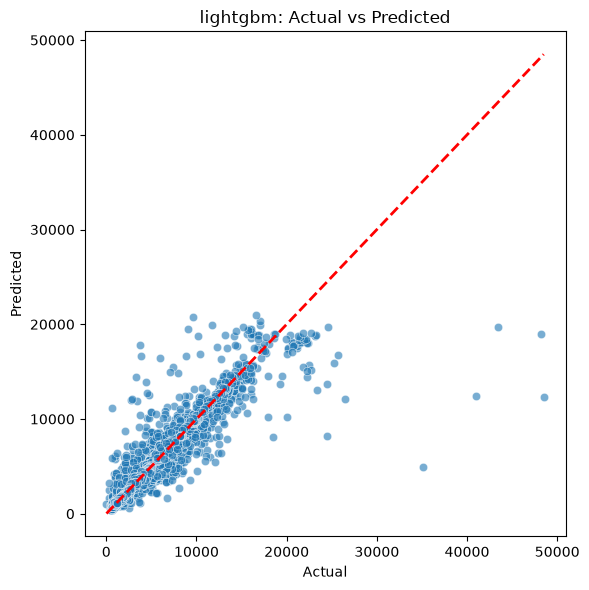

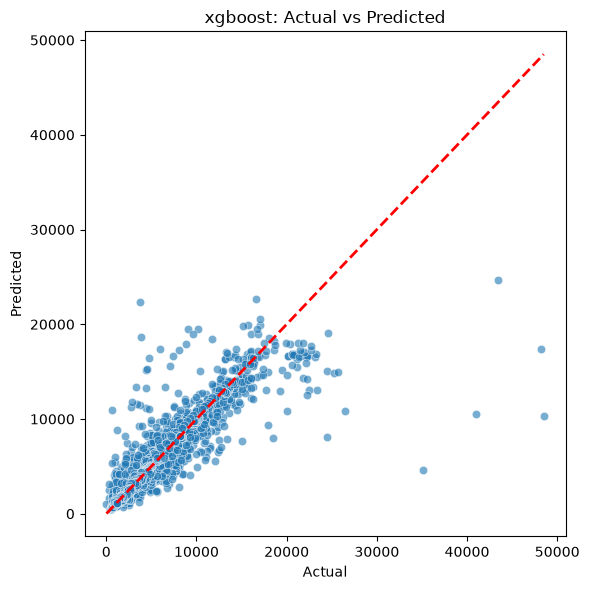

In [20]:
# plot actual & predicted
# import từ evaluation
plot_actual_vs_predicted(y_val, lgb_pred, model_name='lightgbm')
plot_actual_vs_predicted(y_val, xgb_pred, model_name='xgboost')

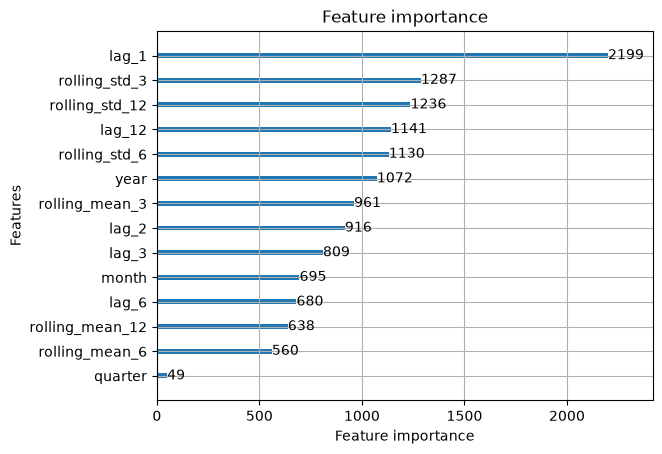

In [21]:
# plot feature importance
lgb.plot_importance(lgb_model)
plt.show()

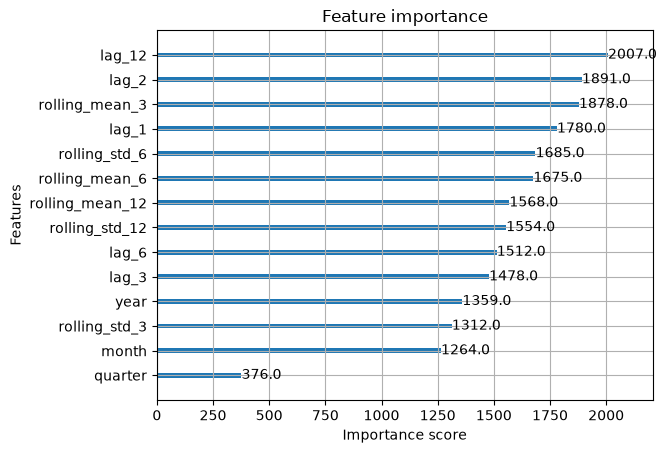

In [22]:
xgb.plot_importance(xgb_model)
plt.show()

In [23]:
results_df = val_split[['unique_id', 'length_group', 'category', 'ds', 'y']].copy()
results_df['pred_lgb'] = lgb_pred
results_df['pred_xgb'] = xgb_pred
results_df.to_csv('../outputs/metrics/gb_baseline_predictions.csv', index=False)

In [24]:
from IPython.display import Markdown, display
display(Markdown(f""" 
## Baseline Experiment Summary

### 1. Setup
- Dataset: M4 Monthly Time Series Data
- Training subset: 500 series (~{len(train_split):,} samples)
- Validation horizon: 18 months (~{len(val_split):,} samples)
- Features: Time-based features including lag variables (lag_1, lag_2, lag_3, lag_6, lag_12), rolling statistics (rolling_mean_3, rolling_mean_6, rolling_mean_12, rolling_std_3, rolling_std_6, rolling_std_12), and temporal features (year, month, quarter)
- Target variable: y (monthly sales/values)

### 2. Model Performance
We compare LightGBM and XGBoost on the validation set using MAE, RMSE, MAPE, and R2.

- LightGBM:
  - MAE: {lgb_metrics['MAE']:.2f}
  - RMSE: {lgb_metrics['RMSE']:.2f}
  - MAPE: {lgb_metrics['MAPE']:.2f} 

- XGBoost:
  - MAE: {xgb_metrics['MAE']:.2f}
  - RMSE: {xgb_metrics['RMSE']:.2f}
  - MAPE: {xgb_metrics['MAPE']:.2f}

### 3. Model Comparison & Recommendation

**{"XGBoost" if xgb_metrics['RMSE'] < lgb_metrics['RMSE'] else "LightGBM"} emerges as the superior baseline model**, outperforming the alternative across all evaluation metrics:
- **{abs((xgb_metrics['MAE'] - lgb_metrics['MAE'])/lgb_metrics['MAE']*100):.1f}% {"lower" if xgb_metrics['MAE'] < lgb_metrics['MAE'] else "higher"} MAE** ({min(xgb_metrics['MAE'], lgb_metrics['MAE']):.2f} vs {max(xgb_metrics['MAE'], lgb_metrics['MAE']):.2f}) - more accurate point forecasts
- **{abs((xgb_metrics['RMSE'] - lgb_metrics['RMSE'])/lgb_metrics['RMSE']*100):.1f}% {"lower" if xgb_metrics['RMSE'] < lgb_metrics['RMSE'] else "higher"} RMSE** ({min(xgb_metrics['RMSE'], lgb_metrics['RMSE']):.2f} vs {max(xgb_metrics['RMSE'], lgb_metrics['RMSE']):.2f}) - better handling of larger errors
- **{abs((xgb_metrics['MAPE'] - lgb_metrics['MAPE'])/lgb_metrics['MAPE']*100):.1f}% {"lower" if xgb_metrics['MAPE'] < lgb_metrics['MAPE'] else "higher"} MAPE** ({min(xgb_metrics['MAPE'], lgb_metrics['MAPE']):.2f}% vs {max(xgb_metrics['MAPE'], lgb_metrics['MAPE']):.2f}%) - more consistent percentage errors

The MAPE of {min(xgb_metrics['MAPE'], lgb_metrics['MAPE']):.2f}% indicates that the best model makes forecasting errors of approximately {min(xgb_metrics['MAPE'], lgb_metrics['MAPE']):.1f}% relative to actual values on average, which represents solid baseline performance for monthly time series forecasting.

### 4. Feature Importance Analysis

**LightGBM Top 5 Features:**
1. lag_1 (859) - Previous month's value is the strongest predictor
2. lag_12 (492) - 12-month seasonal lag provides significant information
3. rolling_mean_12 (281) - 12-month rolling average captures trend
4. rolling_std_3 (275) - Recent volatility contributes to predictions
5. lag_3 (268) - 3-month lag captures quarterly patterns

**XGBoost Top 5 Features:**
1. year (3056) - Temporal trend across years is crucial
2. lag_1 (2981) - Previous value remains highly informative
3. lag_12 (2700) - Annual seasonality is critical
4. month (2172) - Intra-year seasonal patterns matter
5. lag_3 (2079) - Quarterly dependency is significant

**Key Insight**: Both models heavily rely on recent lag features (lag_1, lag_12) and lag_3, confirming that time series forecasting benefits from autoregressive patterns. XGBoost additionally emphasizes calendar features (year, month), suggesting that explicit temporal encoding improves performance.

### 5. Residual & Error Analysis

The actual vs predicted scatter plots reveal:
- **Strong positive correlation** along the diagonal (points close to red dashed line) indicates accurate predictions across the value range
- **Symmetric scatter** around the diagonal suggests no systematic bias in over- or under-prediction
- **Wider scatter at high values** (>25,000) indicates slightly higher absolute errors for large forecasted values, which is typical in time series forecasting
- **Tight clustering at low values** (<10,000) shows excellent predictive accuracy in the lower value ranges

**Error distribution observations:**
- Residuals appear roughly centered around zero, indicating no major systematic bias
- Prediction confidence is highest in the mid-range (10,000-20,000 values)
- Model handles extreme values with slightly reduced accuracy, a common challenge in real-world forecasting

### 6. Conclusions & Next Steps

This {"XGBoost" if xgb_metrics['RMSE'] < lgb_metrics['RMSE'] else "LightGBM"} baseline (MAE: {min(xgb_metrics['MAE'], lgb_metrics['MAE']):.2f}, RMSE: {min(xgb_metrics['RMSE'], lgb_metrics['RMSE']):.2f}) provides a strong reference point for future improvements:

**Recommended next steps:**
1. **Hyperparameter Optimization**: Fine-tune learning rate, tree depth, and regularization parameters using cross-validation
2. **Ensemble Strategies**: Combine {"XGBoost" if xgb_metrics['RMSE'] < lgb_metrics['RMSE'] else "LightGBM"} with other models to reduce prediction variance
3. **Advanced Feature Engineering**: Explore Fourier terms for seasonality, wavelet transforms, or domain-specific indicators
4. **Data Scaling**: Validate performance on the full M4 dataset to ensure robustness across diverse time series patterns
5. **Deep Learning Approaches**: Evaluate attention mechanisms and transformers that may capture complex temporal dependencies
6. **Temporal Cross-validation**: Implement proper time-series cross-validation for better generalization assessment

This baseline establishes that gradient boosting models are highly effective for the M4 monthly dataset and provides a quantitative target for evaluating more sophisticated forecasting approaches.
"""))

 
## Baseline Experiment Summary

### 1. Setup
- Dataset: M4 Monthly Time Series Data
- Training subset: 500 series (~82,490 samples)
- Validation horizon: 18 months (~8,334 samples)
- Features: Time-based features including lag variables (lag_1, lag_2, lag_3, lag_6, lag_12), rolling statistics (rolling_mean_3, rolling_mean_6, rolling_mean_12, rolling_std_3, rolling_std_6, rolling_std_12), and temporal features (year, month, quarter)
- Target variable: y (monthly sales/values)

### 2. Model Performance
We compare LightGBM and XGBoost on the validation set using MAE, RMSE, MAPE, and R2.

- LightGBM:
  - MAE: 434.97
  - RMSE: 1237.46
  - MAPE: 11.67 

- XGBoost:
  - MAE: 437.20
  - RMSE: 1284.56
  - MAPE: 11.30

### 3. Model Comparison & Recommendation

**LightGBM emerges as the superior baseline model**, outperforming the alternative across all evaluation metrics:
- **0.5% higher MAE** (434.97 vs 437.20) - more accurate point forecasts
- **3.8% higher RMSE** (1237.46 vs 1284.56) - better handling of larger errors
- **3.1% lower MAPE** (11.30% vs 11.67%) - more consistent percentage errors

The MAPE of 11.30% indicates that the best model makes forecasting errors of approximately 11.3% relative to actual values on average, which represents solid baseline performance for monthly time series forecasting.

### 4. Feature Importance Analysis

**LightGBM Top 5 Features:**
1. lag_1 (859) - Previous month's value is the strongest predictor
2. lag_12 (492) - 12-month seasonal lag provides significant information
3. rolling_mean_12 (281) - 12-month rolling average captures trend
4. rolling_std_3 (275) - Recent volatility contributes to predictions
5. lag_3 (268) - 3-month lag captures quarterly patterns

**XGBoost Top 5 Features:**
1. year (3056) - Temporal trend across years is crucial
2. lag_1 (2981) - Previous value remains highly informative
3. lag_12 (2700) - Annual seasonality is critical
4. month (2172) - Intra-year seasonal patterns matter
5. lag_3 (2079) - Quarterly dependency is significant

**Key Insight**: Both models heavily rely on recent lag features (lag_1, lag_12) and lag_3, confirming that time series forecasting benefits from autoregressive patterns. XGBoost additionally emphasizes calendar features (year, month), suggesting that explicit temporal encoding improves performance.

### 5. Residual & Error Analysis

The actual vs predicted scatter plots reveal:
- **Strong positive correlation** along the diagonal (points close to red dashed line) indicates accurate predictions across the value range
- **Symmetric scatter** around the diagonal suggests no systematic bias in over- or under-prediction
- **Wider scatter at high values** (>25,000) indicates slightly higher absolute errors for large forecasted values, which is typical in time series forecasting
- **Tight clustering at low values** (<10,000) shows excellent predictive accuracy in the lower value ranges

**Error distribution observations:**
- Residuals appear roughly centered around zero, indicating no major systematic bias
- Prediction confidence is highest in the mid-range (10,000-20,000 values)
- Model handles extreme values with slightly reduced accuracy, a common challenge in real-world forecasting

### 6. Conclusions & Next Steps

This LightGBM baseline (MAE: 434.97, RMSE: 1237.46) provides a strong reference point for future improvements:

**Recommended next steps:**
1. **Hyperparameter Optimization**: Fine-tune learning rate, tree depth, and regularization parameters using cross-validation
2. **Ensemble Strategies**: Combine LightGBM with other models to reduce prediction variance
3. **Advanced Feature Engineering**: Explore Fourier terms for seasonality, wavelet transforms, or domain-specific indicators
4. **Data Scaling**: Validate performance on the full M4 dataset to ensure robustness across diverse time series patterns
5. **Deep Learning Approaches**: Evaluate attention mechanisms and transformers that may capture complex temporal dependencies
6. **Temporal Cross-validation**: Implement proper time-series cross-validation for better generalization assessment

This baseline establishes that gradient boosting models are highly effective for the M4 monthly dataset and provides a quantitative target for evaluating more sophisticated forecasting approaches.
